# RNAAPIA — Optuna Hyperparameter Optimization (v9)

**Objetivo:** encontrar os melhores hiperparâmetros para FaceCNN e ResNet-50
usando Optuna (TPE Sampler + Pruning) a partir dos pesos já treinados.

**Resultados de referência (v8):**
- FaceCNN:  91.39% val | 90.72% test | AUC 99.70%
- ResNet-50: 93.35% val | 93.76% test | AUC 99.89%

**Hiperparâmetros a otimizar:**

| Parâmetro | Tipo | Intervalo |
|-----------|------|----------|
| learning_rate | float (log) | 1e-5 → 1e-2 |
| weight_decay | float (log) | 1e-5 → 1e-2 |
| dropout | float | 0.2 → 0.6 |
| label_smoothing | float | 0.0 → 0.2 |
| batch_size | categorical | 32, 64, 128 |
| scheduler | categorical | cosine, step, plateau |

```
0. Setup
1. Dataset (reutilizar dataset alinhado)
2. Definição dos modelos (flexíveis)
3. Objective function — Optuna
4. Study FaceCNN — N trials
5. Study ResNet-50 — N trials
6. Análise dos resultados
7. Treino final com melhores hiperparâmetros
8. Guardar resultados em CSV
```

## ⚠️ Antes de começar
1. **Add Data** → `hearfool/vggface2`
2. **Add Data** → Models → `facecnn` e `resnet-50`
3. **Add Data** → `dataset-metadata-json` e `dataset-metadata-v7-json`
4. **Settings** → Accelerator → GPU T4
5. Corre as células por ordem

---
## 0. Setup

In [1]:
# Faz o setup inicial do ambiente e confirma se a aceleração por GPU está disponível.
# O Optuna executa muitos trials, por isso esta validação evita desperdício de tempo computacional.
import torch, os, glob, json

print(f'CUDA disponível: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CUDA disponível: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
%%capture
# Instala o Optuna e restantes dependências usadas durante a pesquisa de hiperparâmetros.
# O notebook esconde o detalhe da instalação para manter o foco no processo experimental.
!pip install optuna optuna-dashboard facenet-pytorch==2.5.3 tqdm matplotlib scikit-learn
print('✓ Dependências instaladas')

In [4]:
# Define a estrutura de pastas onde serão guardados checkpoints, logs e bases de dados do Optuna.
# Manter estes caminhos centralizados facilita retomar estudos e guardar resultados.
BASE = '/kaggle/working'

PATHS = {
    'raw'        : '/kaggle/input/datasets/hearfool/vggface2/train',
    'aligned'    : f'{BASE}/vggface2_aligned',
    'checkpoints': f'{BASE}/checkpoints',
    'logs'       : f'{BASE}/logs',
    'optuna'     : f'{BASE}/optuna',
}
for k, v in PATHS.items():
    if k != 'raw':
        os.makedirs(v, exist_ok=True)

# Paths dos checkpoints v8
CNN_CKPT_IN    = '/kaggle/input/models/goncalojesus/facecnn/pytorch/default/1/best_cnn.pth'
RESNET_CKPT_IN = '/kaggle/input/models/goncalojesus/resnet-50/pytorch/default/1/best_resnet.pth'

# Metadata — usar v7 (70 identidades) se disponível, senão v5 (50)
METADATA_PATH = None
for candidate in [
    '/kaggle/input/datasets/goncalojesus/dataset-metadata-v7-json/dataset_metadata_v7.json',
    '/kaggle/input/datasets/goncalojesus/dataset-metadata-json/dataset_metadata.json',
]:
    if os.path.exists(candidate):
        METADATA_PATH = candidate
        print(f'✓ Metadata: {candidate}')
        break

# Configuração fixa
IMAGE_SIZE     = 192
EMBEDDING_SIZE = 512
N_TRIALS_CNN   = 20   # trials Optuna para FaceCNN
N_TRIALS_RN    = 20   # trials Optuna para ResNet-50
EPOCHS_TRIAL   = 10   # épocas por trial (rápido — o pruner elimina os maus)
EPOCHS_FINAL   = 50   # épocas treino final com melhores hiperparâmetros

# Referências v8
PREV_BEST_CNN    = 0.9072  # test accuracy
PREV_BEST_RESNET = 0.9376  # test accuracy

print(f'\nConfiguração:')
print(f'  N_TRIALS: CNN={N_TRIALS_CNN} | ResNet={N_TRIALS_RN}')
print(f'  EPOCHS_TRIAL={EPOCHS_TRIAL} | EPOCHS_FINAL={EPOCHS_FINAL}')
print(f'  Referências — CNN: {PREV_BEST_CNN*100:.2f}% | ResNet: {PREV_BEST_RESNET*100:.2f}%')

✓ Metadata: /kaggle/input/datasets/goncalojesus/dataset-metadata-json/dataset_metadata.json

Configuração:
  N_TRIALS: CNN=20 | ResNet=20
  EPOCHS_TRIAL=10 | EPOCHS_FINAL=50
  Referências — CNN: 90.72% | ResNet: 93.76%


---
## 1. Dataset
Reutiliza o dataset já alinhado. Se não existir, corre o MTCNN.

In [13]:
# Reutiliza o dataset alinhado e, caso falte, prepara a lógica para alinhar rostos com MTCNN.
# Isto garante que a otimização trabalha sobre dados consistentes com as experiências anteriores.
from facenet_pytorch import MTCNN
from PIL import Image
import glob, shutil, json
from tqdm import tqdm

# Definir identidades a usar
all_identities = sorted(os.listdir(PATHS['raw']))
if METADATA_PATH and os.path.exists(METADATA_PATH):
    with open(METADATA_PATH) as f:
        metadata = json.load(f)
    identities_to_use = metadata['identities']
    print(f'✓ {len(identities_to_use)} identidades do metadata')
else:
    identities_to_use = all_identities[:70]
    print(f'Sem metadata — a usar primeiras 70 identidades')

# Inicializar MTCNN
margin = max(20, IMAGE_SIZE // 6)
mtcnn  = MTCNN(image_size=IMAGE_SIZE, margin=margin,
               min_face_size=20, post_process=False, device=device)

already_done = set(os.listdir(PATHS['aligned'])) if os.path.exists(PATHS['aligned']) else set()
remaining    = [i for i in identities_to_use if i not in already_done]
print(f'Já alinhadas: {len(already_done)} | Por alinhar: {len(remaining)}')

total_saved, failed = 0, 0
for identity in tqdm(remaining, desc='MTCNN'):
    out_dir   = os.path.join(PATHS['aligned'], identity)
    os.makedirs(out_dir, exist_ok=True)
    img_paths = (glob.glob(os.path.join(PATHS['raw'], identity, '*.jpg')) +
                 glob.glob(os.path.join(PATHS['raw'], identity, '*.png')))[:350]
    saved = 0
    for p in img_paths:
        try:
            face = mtcnn(Image.open(p).convert('RGB'))
            if face is not None:
                Image.fromarray(face.permute(1,2,0).byte().numpy()).save(
                    os.path.join(out_dir, os.path.basename(p)))
                saved += 1
        except Exception:
            failed += 1
    if saved < 20:
        shutil.rmtree(out_dir)
    else:
        total_saved += saved

total_imgs = sum(len(os.listdir(os.path.join(PATHS['aligned'], d)))
                 for d in os.listdir(PATHS['aligned']))
print(f'✓ MTCNN: {len(os.listdir(PATHS["aligned"]))} identidades | {total_saved} novas | {total_imgs} total | {failed} falhas')

✓ 50 identidades do metadata
Já alinhadas: 0 | Por alinhar: 50


MTCNN: 100%|██████████| 50/50 [12:29<00:00, 14.99s/it]

✓ MTCNN: 50 identidades | 15398 novas | 15398 total | 0 falhas


In [14]:
# Constrói o dataset base e divide-o em treino, validação e teste.
# Aqui o augmentation ainda não é aplicado para permitir que cada trial defina a sua própria configuração.
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms

# Dataset base (sem augmentation — aplicado dinamicamente na objective)
base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(PATHS['aligned'], transform=base_transform)
NUM_CLASSES  = len(full_dataset.classes)
total        = len(full_dataset)
n_train = int(0.70 * total)
n_val   = int(0.15 * total)
n_test  = total - n_train - n_val

train_set, val_set, test_set = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

print(f'Classes: {NUM_CLASSES} | Total: {total}')
print(f'Train: {n_train} | Val: {n_val} | Test: {n_test}')

Classes: 50 | Total: 15398
Train: 10778 | Val: 2309 | Test: 2311


---
## 2. Definição dos Modelos (Flexíveis para Optuna)

In [ ]:
# Define as arquiteturas flexíveis da FaceCNN e da ResNet que serão testadas pelo Optuna.
# A intenção é permitir variar hiperparâmetros sem reescrever o pipeline principal.
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

# Bloco Convolucional reutilizável
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Sequência padrão: Convolução -> Normalização -> Ativação -> Redução de dimensionalidade
        self.block = nn.Sequential(
            # padding=1 mantém o tamanho espacial da imagem (antes do Pooling)
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),  # Aprende filtros sobre pequenas regiões da face.
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(inplace=True), 
            nn.MaxPool2d(2)) # Reduz largura e altura a metade
            
    def forward(self, x): 
        return self.block(x)

# Arquitetura de rede customizada para Reconhecimento Facial
# FaceCNN: 4 camadas convolucionais (nos 4 ConvBlock) + 2 camadas densas (embedding + classifier)
class FaceCNN(nn.Module):
    def __init__(self, num_classes, embedding_size=512, image_size=192, dropout=0.5):
        super().__init__()
        # 4 blocos que reduzem a imagem de 192x192 para 12x12 (192 / 2^4)
        # Parte convolucional da FaceCNN: 4 camadas Conv2d no total.
        self.conv_blocks = nn.Sequential(
            ConvBlock(3, 32), ConvBlock(32, 64),
            ConvBlock(64, 128), ConvBlock(128, 256))
        
        # Cálculo dinâmico do tamanho do feature map após as convoluções
        fm        = image_size // 16 # 16 = 2 (do pooling) elevado a 4 blocos
        flat_size = 256 * fm * fm
        
        # Camada que gera o "vetor de identidade" (embedding)
        # Parte densa da FaceCNN: 1 camada Linear para embedding.
        # Primeira camada densa adicional da ResNet50Face: projeta as features para o embedding facial.
        self.embedding = nn.Sequential(
            nn.Flatten(), 
            nn.Dropout(p=dropout),
            nn.Linear(flat_size, embedding_size),
            nn.BatchNorm1d(embedding_size), 
            nn.ReLU(inplace=True))
        
        # Camada de classificação final (usada apenas durante o treino)
        # Segunda camada densa da FaceCNN: classificação final por identidade.
        # Segunda camada densa adicional da ResNet50Face: classificação final.
        self.classifier = nn.Linear(embedding_size, num_classes)
        
    def forward(self, x, return_embedding=False):
        # Extrai features convolucionais e gera o embedding
        emb = self.embedding(self.conv_blocks(x))
        # Se return_embedding for True, retorna o vetor normalizado (útil para inferência/comparação)
        # Caso contrário, retorna os logits da classificação (útil para treino com CrossEntropy)
        return F.normalize(emb, dim=1) if return_embedding else self.classifier(emb)  # Embeddings normalizados permitem comparação por cosseno.

# Alternativa usando ResNet50 como base (Transfer Learning)
# ResNet50Face: backbone ResNet-50 com 49 camadas convolucionais + 2 camadas densas no topo (embedding + classifier)
class ResNet50Face(nn.Module):
    def __init__(self, num_classes, embedding_size=512, dropout=0.5):
        super().__init__()
        # Carrega a ResNet50 pré-treinada (weights=null indica que o utilizador carregará depois ou quer aleatória)
        # Parte convolucional da ResNet50Face: as convoluções ficam dentro do backbone ResNet-50.
        backbone       = tv_models.resnet50(weights=None)
        # Remove a última camada (FC) para usar as features globais (2048 canais)
        self.features  = nn.Sequential(*list(backbone.children())[:-1])
        
        # Cabeçalho para mapear as features da ResNet para o tamanho de embedding desejado
        # Parte densa da FaceCNN: 1 camada Linear para embedding.
        # Primeira camada densa adicional da ResNet50Face: projeta as features para o embedding facial.
        self.embedding = nn.Sequential(
            nn.Flatten(), 
            nn.Dropout(p=dropout),
            nn.Linear(2048, embedding_size),
            nn.BatchNorm1d(embedding_size), 
            nn.ReLU(inplace=True))
        
        # Segunda camada densa da FaceCNN: classificação final por identidade.
        # Segunda camada densa adicional da ResNet50Face: classificação final.
        self.classifier = nn.Linear(embedding_size, num_classes)
        
    def forward(self, x, return_embedding=False):
        emb = self.embedding(self.features(x))
        return F.normalize(emb, dim=1) if return_embedding else self.classifier(emb)  # Embeddings normalizados permitem comparação por cosseno.

def load_partial_weights(model, ckpt_path, device):
    """
    Carrega pesos compatíveis de um ficheiro de checkpoint (.pth/.pt).
    Ignora a camada 'classifier' se o número de classes no checkpoint for diferente do modelo local.
    """
    if not ckpt_path or not os.path.exists(ckpt_path):
        return
        
    # Carrega o estado guardado
    state      = torch.load(ckpt_path, map_location=device)['model']
    model_dict = model.state_dict()
    
    # Filtra as camadas: devem existir no modelo atual, não ser o classificador e ter o mesmo formato (shape)
    to_load    = {k: v for k, v in state.items()
                  if k in model_dict and 'classifier' not in k
                  and v.shape == model_dict[k].shape}
    
    # Faz o update e carrega os pesos no modelo real
    model_dict.update(to_load)
    model.load_state_dict(model_dict)

print('✓ Modelos definidos')


✓ Modelos definidos


---
## 3. Objective Function — Optuna
Cada trial sugere hiperparâmetros, treina por `EPOCHS_TRIAL` épocas e reporta
a val accuracy. O pruner (MedianPruner) elimina trials que ficam abaixo da mediana.

In [18]:
# Implementa a objective function, ou seja, a rotina que cada trial executa.
# É aqui que o Optuna sugere parâmetros, treina por algumas épocas e reporta a val accuracy.
import optuna
import time
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, ReduceLROnPlateau
optuna.logging.set_verbosity(optuna.logging.WARNING)

def get_loaders(batch_size):
    """Cria DataLoaders com o batch_size do trial."""
    aug_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Mantém input consistente entre trials.
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomGrayscale(p=0.05),
        transforms.RandomApply([transforms.GaussianBlur(3)], p=0.1),
        transforms.RandomApply([transforms.RandomRotation(15)], p=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
        transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    ])
    val_transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    # Aplicar transforms corretos a cada subset
    train_ds = datasets.ImageFolder(PATHS['aligned'], transform=aug_transform)
    val_ds   = datasets.ImageFolder(PATHS['aligned'], transform=val_transform)
    train_ds = Subset(train_ds, train_set.indices)
    val_ds   = Subset(val_ds,   val_set.indices)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, val_loader


# Esta função devolve a objective que o Optuna vai chamar em cada trial.
# Cada trial corresponde a uma tentativa completa com uma combinação diferente de hiperparâmetros.
def make_objective(model_type, ckpt_path):
    """Cria a função objective para o model_type ('cnn' ou 'resnet')."""

    def objective(trial):
        # ── Sugerir hiperparâmetros ───────────────────────────────────────────
        # O Optuna escolhe aqui os valores a testar neste trial.
        # Em vez de definirmos manualmente um único valor, deixamos o sampler explorar o espaço de pesquisa.
        lr             = trial.suggest_float('lr',             1e-5, 1e-2, log=True)
        weight_decay   = trial.suggest_float('weight_decay',   1e-5, 1e-2, log=True)
        dropout        = trial.suggest_float('dropout',        0.2,  0.6)
        label_smoothing= trial.suggest_float('label_smoothing',0.0,  0.2)
        batch_size     = trial.suggest_categorical('batch_size', [32, 64, 128])
        scheduler_name = trial.suggest_categorical('scheduler',  ['cosine', 'step', 'plateau'])

        # ── Construir modelo ──────────────────────────────────────────────────
        # Depois de escolher os hiperparâmetros, o trial constrói o modelo correspondente.
        # Isto garante que cada combinação é avaliada de forma consistente.
        if model_type == 'cnn':
            model = FaceCNN(NUM_CLASSES, EMBEDDING_SIZE, IMAGE_SIZE, dropout).to(device)
        else:
            model = ResNet50Face(NUM_CLASSES, EMBEDDING_SIZE, dropout).to(device)
        load_partial_weights(model, ckpt_path, device)

        # ── Otimizador e scheduler ────────────────────────────────────────────
        # O otimizador e o scheduler também dependem dos valores sugeridos pelo trial.
        # Assim, o desempenho observado já reflete o efeito da hiperparametrização completa.
        optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        if scheduler_name == 'cosine':
            scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_TRIAL, eta_min=1e-7)
        elif scheduler_name == 'step':
            scheduler = StepLR(optimizer, step_size=max(1, EPOCHS_TRIAL//3), gamma=0.5)
        else:
            scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

        scaler = torch.amp.GradScaler('cuda')
        train_loader, val_loader = get_loaders(batch_size)

        # ── Treino ────────────────────────────────────────────────────────────
        # Cada trial treina durante algumas épocas e guarda a melhor accuracy de validação alcançada.
        # Essa melhor métrica é a pontuação final do trial dentro da study.
        best_val_acc = 0.0
        for epoch in tqdm(range(EPOCHS_TRIAL), desc=f'  Trial {trial.number}', leave=False):
            model.train()
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    loss = F.cross_entropy(model(imgs), labels,
                                          label_smoothing=label_smoothing)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()

            # Avaliação
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    out = model(imgs).float()
                    correct += (out.argmax(1) == labels).sum().item()
                    total   += imgs.size(0)
            val_acc = correct / total
            if val_acc > best_val_acc:
                best_val_acc = val_acc

            # Scheduler step
            # O scheduler é atualizado a cada época conforme a estratégia escolhida pelo próprio trial.
            if scheduler_name == 'plateau':
                scheduler.step(val_acc)
            else:
                scheduler.step()

            # Reportar ao Optuna — permite pruning
            # trial.report envia ao Optuna a métrica intermédia desta época.
            # Isto permite acompanhar o progresso do trial e decidir se vale a pena continuar.
            trial.report(val_acc, epoch)
            # Se o trial estiver claramente pior do que outros já observados,
            # o pruner interrompe-o cedo para poupar tempo e computação.
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        # No fim, o Optuna recebe a melhor val_acc deste trial e usa-a para comparar com os restantes.
        return best_val_acc

    return objective

print('✓ Objective function definida')

✓ Objective function definida


---
## 4. Study FaceCNN
`N_TRIALS_CNN` trials com TPE Sampler + MedianPruner.

In [21]:
# Tenta recuperar bases de dados de estudos já existentes para continuar a pesquisa do ponto anterior.
# Isto evita começar do zero quando já existem trials guardados externamente.
for db_name in ['cnn_study.db', 'resnet_study.db']:
    src = f'/kaggle/input/datasets/goncalojesus/rnaapia-optuna-studies/{db_name}'
    dst = f'{PATHS["optuna"]}/{db_name}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'✓ {db_name} carregado')
    else:
        print(f'⚠️  {db_name} não encontrado em {src}')

✓ cnn_study.db carregado
⚠️  resnet_study.db não encontrado em /kaggle/input/datasets/goncalojesus/rnaapia-optuna-studies/resnet_study.db


In [29]:
# Cria ou retoma o estudo Optuna dedicado à FaceCNN.
# O sampler TPE explora o espaço de forma inteligente e o pruner corta trials pouco promissores.
import optuna
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner

# Aqui começa a study da FaceCNN.
# Uma study é o objeto principal do Optuna: guarda trials, melhores parâmetros e histórico da pesquisa.
cnn_study = optuna.create_study(
    direction  = 'maximize',
    # O TPESampler escolhe novos hiperparâmetros com base nos trials anteriores.
    # Em vez de testar ao acaso, tenta concentrar a pesquisa em zonas mais promissoras.
    sampler    = TPESampler(seed=42),
    # O MedianPruner corta trials fracos comparando-os com a mediana dos trials já observados.
    # Isto acelera a pesquisa porque evita desperdiçar épocas em combinações pouco promissoras.
    pruner     = MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    study_name = 'FaceCNN',
    storage    = f'sqlite:///{PATHS["optuna"]}/cnn_study.db',
    load_if_exists = True
)

# Se já existir uma base de dados da study, estes trials são reaproveitados.
# Assim a pesquisa pode ser retomada sem perder o histórico anterior.
already_done_cnn = len(cnn_study.trials)
remaining_trials = max(0, N_TRIALS_CNN - already_done_cnn)
print(f'Trials já concluídos: {already_done_cnn} | Por correr: {remaining_trials}')

if remaining_trials > 0:
    # O método optimize arranca a pesquisa: o Optuna executa vários trials da objective.
    # Cada trial testa uma nova combinação de hiperparâmetros e devolve uma val_acc.
    cnn_study.optimize(
        make_objective('cnn', CNN_CKPT_IN),
        n_trials  = remaining_trials,
        timeout   = 3600,  # máximo 1 hora
        callbacks = [lambda study, trial: print(
            f'  Trial {trial.number:02d} | '
            f'val_acc: {trial.value*100:.2f}% | '
            f'params: lr={trial.params["lr"]:.1e} '
            f'wd={trial.params["weight_decay"]:.1e} '
            f'do={trial.params["dropout"]:.2f} '
            f'ls={trial.params["label_smoothing"]:.2f} '
            f'bs={trial.params["batch_size"]} '
            f'sched={trial.params["scheduler"]}'
        ) if trial.value is not None else print(f'  Trial {trial.number:02d} | PRUNED')]
    )

# Quando a study termina, podemos consultar diretamente o melhor valor e os melhores parâmetros encontrados.
print(f'\n✓ FaceCNN Study concluído!')
print(f'  Melhor val_acc: {cnn_study.best_value*100:.2f}%')
print(f'  Melhores parâmetros:')
for k, v in cnn_study.best_params.items():
    print(f'    {k}: {v}')

Trials já concluídos: 20 | Por correr: 0

✓ FaceCNN Study concluído!
  Melhor val_acc: 95.63%
  Melhores parâmetros:
    lr: 0.00014656553886225324
    weight_decay: 6.516990611177177e-05
    dropout: 0.5314950036607717
    label_smoothing: 0.07135066533871785
    batch_size: 64
    scheduler: plateau


In [15]:
# Copia localmente as bases de dados dos estudos para uma pasta preparada para exportação.
# Assim fica mais fácil descarregar ou reutilizar o histórico completo de otimização.
import subprocess, shutil

studies_dir = f'{BASE}/optuna_studies'
os.makedirs(studies_dir, exist_ok=True)

for db_name in ['cnn_study.db', 'resnet_study.db']:
    src = f'{PATHS["optuna"]}/{db_name}'
    if os.path.exists(src):
        shutil.copy(src, f'{studies_dir}/{db_name}')
        print(f'✓ {db_name} copiado')
    else:
        print(f'⚠️  {db_name} ainda não existe — study não correu')

with open(f'{studies_dir}/dataset-metadata.json', 'w') as f:
    json.dump({'title': 'RNAAPIA Optuna Studies',
               'id': 'goncalojesus/rnaapia-optuna-studies',
               'licenses': [{'name': 'CC0-1.0'}]}, f)

result = subprocess.run(
    ['kaggle', 'datasets', 'create', '-p', studies_dir, '--dir-mode', 'zip'],
    capture_output=True, text=True)
print(result.stdout or result.stderr)

✓ cnn_study.db copiado
⚠️  resnet_study.db ainda não existe — study não correu
Starting upload for file cnn_study.db
Upload successful: cnn_study.db (128KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/goncalojesus/rnaapia-optuna-studies



---
## 5. Study ResNet-50

In [22]:
# Define a versão ResNet-50 usada durante a otimização de hiperparâmetros.
# A estrutura mantém-se compatível com os checkpoints e com a objective function criada acima.
# ResNet50Face: backbone ResNet-50 com 49 camadas convolucionais + 2 camadas densas no topo (embedding + classifier)
class ResNet50Face(nn.Module):
    def __init__(self, num_classes, embedding_size=512, dropout=0.5):
        super().__init__()
        # Parte convolucional da ResNet50Face: as convoluções ficam dentro do backbone ResNet-50.
        backbone       = tv_models.resnet50(weights=None)  # Backbone residual usado também na pesquisa de hiperparâmetros.
        self.features  = nn.Sequential(*list(backbone.children())[:-1])
        # Primeira camada densa adicional da ResNet50Face: projeta as features para o embedding facial.
        self.embedding = nn.Sequential(
            nn.Flatten(), nn.Dropout(p=dropout),  # O dropout também entra no espaço de procura do Optuna.
            nn.Linear(2048, embedding_size),
            nn.BatchNorm1d(embedding_size), nn.ReLU(inplace=True))
        # Segunda camada densa adicional da ResNet50Face: classificação final.
        self.classifier = nn.Linear(embedding_size, num_classes)
    def forward(self, x, return_embedding=False):
        emb = self.embedding(self.features(x))
        return F.normalize(emb, dim=1) if return_embedding else self.classifier(emb)

print('✓ ResNet50Face redefinida')

✓ ResNet50Face redefinida


In [25]:
# Cria ou retoma o estudo Optuna específico para a ResNet-50.
# Tal como na FaceCNN, a execução pode continuar a partir de trials já existentes.
from optuna.samplers import TPESampler
from optuna.pruners  import MedianPruner
# Esta é a study equivalente para a ResNet-50.
# Mantém a mesma lógica da FaceCNN, mas aplicada a uma arquitetura diferente.
rn_study = optuna.create_study(
    direction  = 'maximize',
    # O mesmo sampler é usado para tornar a pesquisa comparável entre modelos.
    sampler    = TPESampler(seed=42),
    # O pruning continua a ser importante aqui, porque a ResNet é mais pesada e cara de treinar.
    pruner     = MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    study_name = 'ResNet50',
    storage    = f'sqlite:///{PATHS["optuna"]}/resnet_study.db',
    load_if_exists = True
)

already_done_rn  = len(rn_study.trials)
remaining_trials = max(0, N_TRIALS_RN - already_done_rn)
print(f'Trials já concluídos: {already_done_rn} | Por correr: {remaining_trials}')

if remaining_trials > 0:
    # O Optuna vai repetir o ciclo trial -> treino -> validação -> comparação,
    # mas agora usando a objective da ResNet-50.
    rn_study.optimize(
        make_objective('resnet', RESNET_CKPT_IN),
        n_trials  = remaining_trials,
        timeout   = 3600,
        callbacks = [lambda study, trial: print(
            f'  Trial {trial.number:02d} | '
            f'val_acc: {trial.value*100:.2f}% | '
            f'params: lr={trial.params["lr"]:.1e} '
            f'wd={trial.params["weight_decay"]:.1e} '
            f'do={trial.params["dropout"]:.2f} '
            f'ls={trial.params["label_smoothing"]:.2f} '
            f'bs={trial.params["batch_size"]} '
            f'sched={trial.params["scheduler"]}'
        ) if trial.value is not None else print(f'  Trial {trial.number:02d} | PRUNED')]
    )

# No fim, best_value e best_params resumem o melhor trial desta arquitetura.
print(f'\n✓ ResNet Study concluído!')
print(f'  Melhor val_acc: {rn_study.best_value*100:.2f}%')
print(f'  Melhores parâmetros:')
for k, v in rn_study.best_params.items():
    print(f'    {k}: {v}')

Trials já concluídos: 0 | Por correr: 20


  Trial 00 | val_acc: 94.80% | params: lr=1.3e-04 wd=7.1e-03 do=0.49 ls=0.12 bs=32 sched=cosine


  Trial 01 | val_acc: 73.84% | params: lr=1.2e-05 wd=8.1e-03 do=0.53 ls=0.04 bs=128 sched=cosine


  Trial 02 | val_acc: 95.63% | params: lr=6.8e-04 wd=2.6e-05 do=0.32 ls=0.07 bs=64 sched=step


  Trial 03 | val_acc: 94.67% | params: lr=6.6e-04 wd=3.2e-05 do=0.23 ls=0.19 bs=32 sched=step


...

  Trial 07 | val_acc: 86.83% | params: lr=2.1e-03 wd=3.9e-05 do=0.20 ls=0.16 bs=128 sched=step


  Trial 08 | val_acc: 45.43% | params: lr=3.9e-03 wd=7.4e-04 do=0.33 ls=0.01 bs=128 sched=step


  Trial 09 | val_acc: 95.67% | params: lr=2.3e-05 wd=1.4e-03 do=0.50 ls=0.11 bs=32 sched=cosine


  Trial 10 | val_acc: 96.41% | params: lr=1.4e-04 wd=1.2e-04 do=0.43 ls=0.07 bs=64 sched=plateau


  Trial 11 | val_acc: 96.58% | params: lr=8.9e-05 wd=1.5e-04 do=0.43 ls=0.07 bs=64 sched=plateau

✓ ResNet Study concluído!
  Melhor val_acc: 96.58%
  Melhores parâmetros:
    lr: 8.875169157251047e-05
    weight_decay: 0.00015043838978395774
    dropout: 0.4282191459526733
    label_smoothing: 0.07224037819201891
    batch_size: 64
    scheduler: plateau


In [27]:
# Replica a exportação dos ficheiros de estudo após a execução da pesquisa.
# Isto protege os resultados obtidos e simplifica a partilha do processo experimental.
import subprocess, shutil

studies_dir = f'{BASE}/optuna_studies'
os.makedirs(studies_dir, exist_ok=True)

for db_name in ['cnn_study.db', 'resnet_study.db']:
    src = f'{PATHS["optuna"]}/{db_name}'
    if os.path.exists(src):
        shutil.copy(src, f'{studies_dir}/{db_name}')
        print(f'✓ {db_name} copiado')
    else:
        print(f'⚠️  {db_name} ainda não existe — study não correu')

with open(f'{studies_dir}/dataset-metadata.json', 'w') as f:
    json.dump({'title': 'RNAAPIA Optuna Studies',
               'id': 'goncalojesus/rnaapia-optuna-studies',
               'licenses': [{'name': 'CC0-1.0'}]}, f)

# Tentar update primeiro, se falhar criar novo
result = subprocess.run(
    ['kaggle', 'datasets', 'version', '-p', studies_dir, '-m', 'Update studies', '--dir-mode', 'zip'],
    capture_output=True, text=True)
print(result.stdout or result.stderr)

✓ cnn_study.db copiado
✓ resnet_study.db copiado
Starting upload for file resnet_study.db
Upload successful: resnet_study.db (124KB)
Starting upload for file cnn_study.db
Upload successful: cnn_study.db (128KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/goncalojesus/rnaapia-optuna-studies



---
## 6. Análise dos Resultados do Optuna

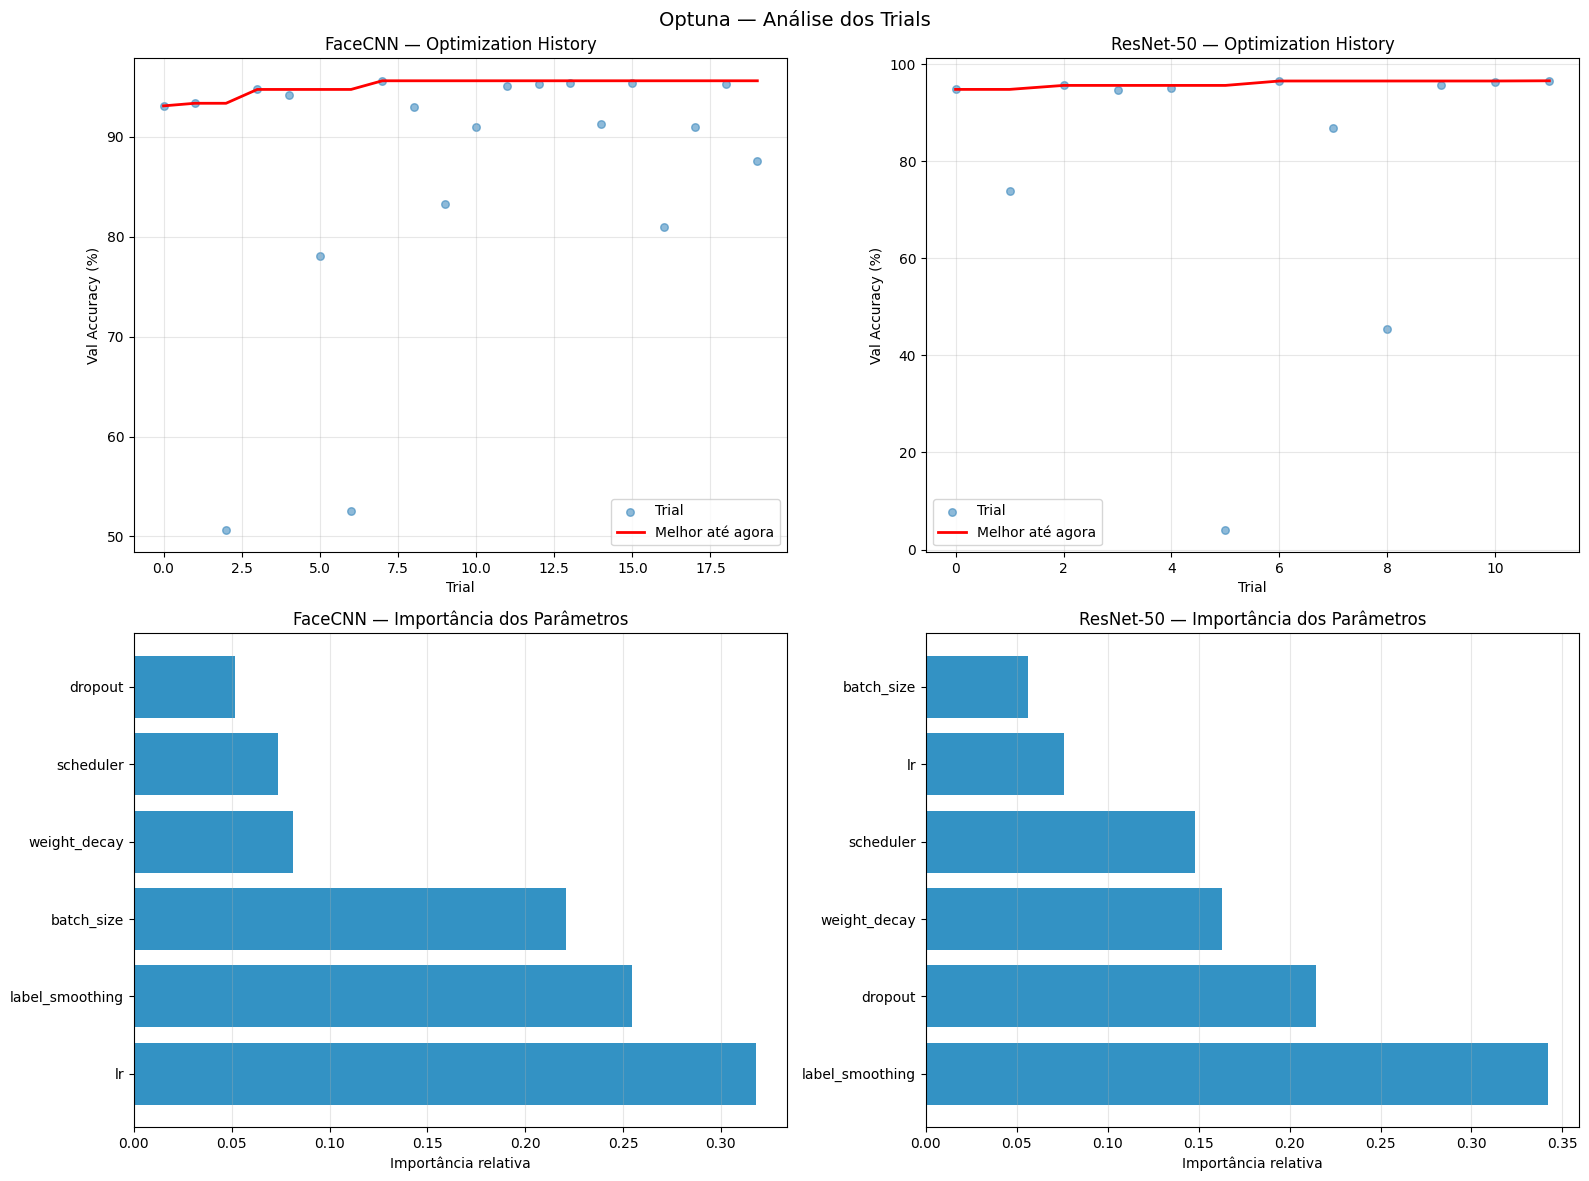


Top 5 trials — FaceCNN:
 Trial  Val Acc       LR       WD  Dropout     LS   BS    Sched
     7   95.63%  1.5e-04  6.5e-05    0.531  0.071   64  plateau
    13   95.45%  1.6e-04  1.0e-05    0.412  0.043   64  plateau
    15   95.41%  1.7e-04  1.1e-04    0.433  0.039   64  plateau
    18   95.32%  2.5e-04  2.1e-05    0.546  0.054   32  plateau
    12   95.28%  3.7e-04  1.2e-05    0.389  0.048   64  plateau

Top 5 trials — ResNet-50:
 Trial  Val Acc       LR       WD  Dropout     LS   BS    Sched
    11   96.58%  8.9e-05  1.5e-04    0.428  0.072   64  plateau
     6   96.54%  1.5e-04  6.5e-05    0.531  0.071   64  plateau
    10   96.41%  1.4e-04  1.2e-04    0.431  0.069   64  plateau
     9   95.67%  2.3e-05  1.4e-03    0.504  0.112   32   cosine
     2   95.63%  6.8e-04  2.6e-05    0.317  0.073   64     step


In [32]:
# Produz gráficos e tabelas para interpretar o comportamento das pesquisas do Optuna.
# O foco aqui é perceber evolução, importância dos parâmetros e combinações mais promissoras.
import matplotlib.pyplot as plt
import pandas as pd
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Optimization history
for ax, study, title in [
    (axes[0,0], cnn_study, 'FaceCNN — Optimization History'),
    (axes[0,1], rn_study,  'ResNet-50 — Optimization History'),
]:
    trials = [t for t in study.trials if t.value is not None]
    vals   = [t.value * 100 for t in trials]
    best   = [max(vals[:i+1]) for i in range(len(vals))]
    ax.scatter(range(len(vals)), vals, alpha=0.5, s=30, label='Trial')
    ax.plot(range(len(best)), best, 'r-', linewidth=2, label='Melhor até agora')
    ax.set_xlabel('Trial'); ax.set_ylabel('Val Accuracy (%)')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

# Importância dos parâmetros
for ax, study, title in [
    (axes[1,0], cnn_study, 'FaceCNN — Importância dos Parâmetros'),
    (axes[1,1], rn_study,  'ResNet-50 — Importância dos Parâmetros'),
]:
    try:
        importances = optuna.importance.get_param_importances(study)
        params = list(importances.keys())
        values = list(importances.values())
        ax.barh(params, values, color='#0077b6', alpha=0.8)
        ax.set_xlabel('Importância relativa'); ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='x')
    except Exception as e:
        ax.text(0.5, 0.5, f'Dados insuficientes\n{e}', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(title)

plt.suptitle('Optuna — Análise dos Trials', fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/optuna_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela dos top 5 trials
for study, name in [(cnn_study, 'FaceCNN'), (rn_study, 'ResNet-50')]:
    trials = sorted([t for t in study.trials if t.value is not None],
                    key=lambda t: t.value, reverse=True)[:5]
    print(f'\nTop 5 trials — {name}:')
    print(f'{"Trial":>6} {"Val Acc":>8} {"LR":>8} {"WD":>8} {"Dropout":>8} {"LS":>6} {"BS":>4} {"Sched":>8}')
    for t in trials:
        p = t.params
        print(f'{t.number:>6} {t.value*100:>7.2f}% {p["lr"]:>8.1e} {p["weight_decay"]:>8.1e} '
              f'{p["dropout"]:>8.3f} {p["label_smoothing"]:>6.3f} {p["batch_size"]:>4} {p["scheduler"]:>8}')

---
## 7. Treino Final com Melhores Hiperparâmetros
Treina ambos os modelos por `EPOCHS_FINAL` épocas com os parâmetros encontrados pelo Optuna.

In [33]:
# Define a rotina de treino final usando os melhores parâmetros encontrados em cada estudo.
# Depois da busca curta por trials, esta função faz um treino mais completo e representativo.
import time

def train_final(model_type, study, ckpt_path, model_name):
    # Depois da pesquisa terminar, study.best_params devolve a melhor combinação encontrada.
    # Esta combinação é então usada num treino final mais completo e representativo.
    best_p = study.best_params
    print(f'\n── Treino final {model_name} ──────────────────────────────────────')
    print(f'  Hiperparâmetros: {best_p}')

    # Modelo
    if model_type == 'cnn':
        model = FaceCNN(NUM_CLASSES, EMBEDDING_SIZE, IMAGE_SIZE, best_p['dropout']).to(device)
    else:
        model = ResNet50Face(NUM_CLASSES, EMBEDDING_SIZE, best_p['dropout']).to(device)
    load_partial_weights(model, ckpt_path, device)

    # DataLoaders com batch_size ótimo
    # Aqui já não estamos a explorar: estamos a reconstruir o treino com os melhores hiperparâmetros da study.
    train_loader, val_loader = get_loaders(best_p['batch_size'])
    test_loader = DataLoader(
        Subset(datasets.ImageFolder(PATHS['aligned'], transform=base_transform), test_set.indices),
        batch_size=best_p['batch_size'], shuffle=False, num_workers=2)

    # O treino final serve para confirmar que os melhores parâmetros encontrados em trials curtos
    # também funcionam bem quando damos mais tempo de treino ao modelo.
    optimizer = Adam(model.parameters(), lr=best_p['lr'], weight_decay=best_p['weight_decay'])  # Usa os hiperparâmetros vencedores da study.
    if best_p['scheduler'] == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_FINAL, eta_min=1e-7)  # LR desce em curva cosseno.
    elif best_p['scheduler'] == 'step':
        scheduler = StepLR(optimizer, step_size=max(1, EPOCHS_FINAL//3), gamma=0.5)  # Reduz o LR em saltos fixos.
    else:
        scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)  # Reduz o LR quando a validação deixa de melhorar.

    scaler   = torch.amp.GradScaler('cuda')
    hist     = []
    best_acc = 0.0
    best_path = f'{BASE}/best_{model_type}_v9.pth'

    for epoch in range(EPOCHS_FINAL):
        t0 = time.time()
        # Train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc='  Train', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            # Nesta fase, a combinação escolhida pelo Optuna é usada como configuração definitiva do treino.
            with torch.amp.autocast('cuda'):
                out  = model(imgs)  # Forward do modelo final com os melhores hiperparâmetros.
                loss = F.cross_entropy(out, labels,
                                       label_smoothing=best_p['label_smoothing'])  # A loss incorpora a melhor suavização encontrada.
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            train_loss    += loss.item() * imgs.size(0)
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total   += imgs.size(0)
        # Val
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc='  Val', leave=False):
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs).float()
                loss = F.cross_entropy(out, labels)
                if not torch.isnan(loss):
                    val_loss += loss.item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += imgs.size(0)

        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total
        elapsed   = time.time() - t0

        if best_p['scheduler'] == 'plateau':
            scheduler.step(val_acc)  # Plateau precisa da métrica de validação para decidir se reduz o LR.
        else:
            scheduler.step()

        improved = ' ✓' if val_acc > best_acc else ''
        print(f'[{model_name}] {epoch+1:02d}/{EPOCHS_FINAL} | '
              f'Train: {train_loss/train_total:.4f} ({train_acc*100:.1f}%) | '
              f'Val: {val_loss/val_total:.4f} ({val_acc*100:.1f}%){improved} | {elapsed:.0f}s')

        hist.append({'epoch': epoch, 'train_acc': round(train_acc,4),
                     'val_acc': round(val_acc,4),
                     'train_loss': round(train_loss/train_total,4),
                     'val_loss': round(val_loss/val_total,4)})

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({'model': model.state_dict(), 'history': hist,
                        'best_params': best_p}, best_path)

    # Test set
    # No final, carregamos o melhor checkpoint guardado durante este treino final
    # para medir o desempenho real no conjunto de teste.
    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt['model'])
    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            test_correct += (model(imgs).argmax(1) == labels).sum().item()
            test_total   += imgs.size(0)
    test_acc = test_correct / test_total

    print(f'\n✓ {model_name} concluído!')
    print(f'  Melhor val acc: {best_acc*100:.2f}%')
    print(f'  Test acc:       {test_acc*100:.2f}%')
    return hist, best_acc, test_acc

print('✓ Função de treino final pronta')

✓ Função de treino final pronta


In [34]:
# Executa o treino final da FaceCNN com os hiperparâmetros vencedores do estudo.
# O resultado inclui histórico, melhor validação e accuracy no conjunto de teste.
from tqdm import tqdm

cnn_hist_final, cnn_best_val, cnn_test_acc = train_final(
    'cnn', cnn_study, CNN_CKPT_IN, 'FaceCNN v9')


── Treino final FaceCNN v9 ──────────────────────────────────────
  Hiperparâmetros: {'lr': 0.00014656553886225324, 'weight_decay': 6.516990611177177e-05, 'dropout': 0.5314950036607717, 'label_smoothing': 0.07135066533871785, 'batch_size': 64, 'scheduler': 'plateau'}


[FaceCNN v9] 01/50 | Train: 2.6832 (49.2%) | Val: 1.3518 (83.5%) ✓ | 24s


[FaceCNN v9] 02/50 | Train: 1.4685 (84.0%) | Val: 0.7506 (90.7%) ✓ | 24s


[FaceCNN v9] 03/50 | Train: 1.1367 (89.6%) | Val: 0.5390 (93.2%) ✓ | 25s


[FaceCNN v9] 04/50 | Train: 0.9900 (92.6%) | Val: 0.4498 (93.9%) ✓ | 25s


...

[FaceCNN v9] 46/50 | Train: 0.6856 (99.0%) | Val: 0.3087 (95.9%) | 24s


[FaceCNN v9] 47/50 | Train: 0.6843 (98.9%) | Val: 0.3038 (96.0%) | 24s


[FaceCNN v9] 48/50 | Train: 0.6848 (99.0%) | Val: 0.3046 (95.8%) | 24s


[FaceCNN v9] 49/50 | Train: 0.6832 (99.0%) | Val: 0.3094 (95.8%) | 24s


[FaceCNN v9] 50/50 | Train: 0.6835 (99.0%) | Val: 0.3029 (95.8%) | 24s

✓ FaceCNN v9 concluído!
  Melhor val acc: 96.06%
  Test acc:       96.24%


In [35]:
# Executa o treino final da ResNet-50 com os melhores hiperparâmetros encontrados.
# Isto permite comparar o ganho real obtido pela otimização em cada arquitetura.
rn_hist_final, rn_best_val, rn_test_acc = train_final(
    'resnet', rn_study, RESNET_CKPT_IN, 'ResNet-50 v9')


── Treino final ResNet-50 v9 ──────────────────────────────────────
  Hiperparâmetros: {'lr': 8.875169157251047e-05, 'weight_decay': 0.00015043838978395774, 'dropout': 0.4282191459526733, 'label_smoothing': 0.07224037819201891, 'batch_size': 64, 'scheduler': 'plateau'}


[ResNet-50 v9] 01/50 | Train: 2.6226 (59.0%) | Val: 1.2488 (89.5%) ✓ | 39s


[ResNet-50 v9] 02/50 | Train: 1.3439 (88.5%) | Val: 0.5782 (94.9%) ✓ | 39s


[ResNet-50 v9] 03/50 | Train: 1.0017 (92.4%) | Val: 0.3930 (95.8%) ✓ | 38s


[ResNet-50 v9] 04/50 | Train: 0.8772 (93.9%) | Val: 0.3313 (95.5%) | 39s


...

[ResNet-50 v9] 46/50 | Train: 0.6220 (99.2%) | Val: 0.2168 (97.1%) | 39s


[ResNet-50 v9] 47/50 | Train: 0.6198 (99.4%) | Val: 0.2168 (97.2%) | 39s


[ResNet-50 v9] 48/50 | Train: 0.6230 (99.3%) | Val: 0.2147 (97.1%) | 39s


[ResNet-50 v9] 49/50 | Train: 0.6218 (99.3%) | Val: 0.2206 (97.1%) | 38s


[ResNet-50 v9] 50/50 | Train: 0.6222 (99.3%) | Val: 0.2186 (97.2%) | 39s

✓ ResNet-50 v9 concluído!
  Melhor val acc: 97.31%
  Test acc:       97.01%


---
## 8. Guardar Resultados em CSV + Kaggle Dataset

In [36]:
# Converte os resultados dos trials em tabelas CSV para análise e documentação.
# Guardar tudo em formato tabular facilita relatórios e comparações futuras.
import pandas as pd
import subprocess

# ── 1. Resultados dos trials ──────────────────────────────────────────────────
# Guardamos o histórico completo dos trials para análise posterior.
# Cada linha representa uma tentativa do Optuna com os respetivos parâmetros e resultado.
rows = []
for study, model_name in [(cnn_study, 'FaceCNN'), (rn_study, 'ResNet-50')]:
    for t in study.trials:
        row = {'modelo': model_name, 'trial': t.number,
               'val_acc': round(t.value*100, 4) if t.value else null,
               'state': t.state.name}
        row.update(t.params)
        rows.append(row)
pd.DataFrame(rows).to_csv(f'{BASE}/optuna_trials.csv', index=False)
print('✓ optuna_trials.csv')

# ── 2. Melhores hiperparâmetros ───────────────────────────────────────────────
best_# Guardamos o histórico completo dos trials para análise posterior.
# Cada linha representa uma tentativa do Optuna com os respetivos parâmetros e resultado.
rows = []
for study, model_name, prev, val, test in [
    (cnn_study, 'FaceCNN',   PREV_BEST_CNN,    cnn_best_val,  cnn_test_acc),
    (rn_study,  'ResNet-50', PREV_BEST_RESNET, rn_best_val,   rn_test_acc),
]:
    row = {'modelo': model_name,
           'prev_test_acc': round(prev*100, 2),
           'v9_val_acc':    round(val*100,  2),
           'v9_test_acc':   round(test*100, 2),
           'delta':         round((test - prev)*100, 2)}
    row.update({f'best_{k}': v for k, v in study.best_params.items()})
    best_rows.append(row)
best_df = pd.DataFrame(best_rows)
best_df.to_csv(f'{BASE}/optuna_best_params.csv', index=False)
print('✓ optuna_best_params.csv')
print(best_df[['modelo','prev_test_acc','v9_val_acc','v9_test_acc','delta']].to_string(index=False))

# ── 3. Histórico de treino final ──────────────────────────────────────────────
# Além dos trials, também exportamos o histórico do treino final feito com os melhores parâmetros.
cnn_df = pd.DataFrame(cnn_hist_final); cnn_df.insert(0, 'modelo', 'FaceCNN')
rn_df  = pd.DataFrame(rn_hist_final);  rn_df.insert(0,  'modelo', 'ResNet-50')
pd.concat([cnn_df, rn_df]).to_csv(f'{BASE}/v9_training_history.csv', index=False)
print('✓ v9_training_history.csv')

# ── 4. Publicar como Kaggle Dataset ──────────────────────────────────────────
results_dir = f'{BASE}/results_v9'
os.makedirs(results_dir, exist_ok=True)
for f_name in ['optuna_trials.csv', 'optuna_best_params.csv', 'v9_training_history.csv']:
    import shutil
    shutil.copy(f'{BASE}/{f_name}', f'{results_dir}/{f_name}')

with open(f'{results_dir}/dataset-metadata.json', 'w') as f:
    json.dump({'title': 'RNAAPIA Results v9 Optuna',
               'id': 'goncalojesus/rnaapia-results-v9',
               'licenses': [{'name': 'CC0-1.0'}]}, f)

result = subprocess.run(
    ['kaggle', 'datasets', 'create', '-p', results_dir, '--dir-mode', 'zip'],
    capture_output=True, text=True)
print(f'\n✓ Kaggle Dataset: {result.stdout.strip()}')
if result.stderr:
    print(f'  {result.stderr.strip()}')

print(f'\n📁 Ficheiros gerados:')
print('  optuna_trials.csv       — todos os trials (params + val_acc)')
print('  optuna_best_params.csv  — melhores params + comparação v8 vs v9')
print('  v9_training_history.csv — treino final por epoch')
print('  best_cnn_v9.pth         — melhor FaceCNN v9')
print('  best_resnet_v9.pth      — melhor ResNet-50 v9')
print('  optuna/cnn_study.db     — base de dados Optuna (persistente)')
print('  optuna/resnet_study.db  — base de dados Optuna (persistente)')

✓ optuna_trials.csv
✓ optuna_best_params.csv
   modelo  prev_test_acc  v9_val_acc  v9_test_acc  delta
  FaceCNN          90.72       96.06        96.24   5.52
ResNet-50          93.76       97.31        97.01   3.25
✓ v9_training_history.csv

✓ Kaggle Dataset: Starting upload for file optuna_best_params.csv
Upload successful: optuna_best_params.csv (395B)
Starting upload for file optuna_trials.csv
Upload successful: optuna_trials.csv (4KB)
Starting upload for file v9_training_history.csv
Upload successful: v9_training_history.csv (4KB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/goncalojesus/rnaapia-results-v9
  0%|          | 0.00/395 [00:00<?, ?B/s]
100%|██████████| 395/395 [00:00<00:00, 1.08kB/s]

  0%|          | 0.00/3.86k [00:00<?, ?B/s]
100%|██████████| 3.86k/3.86k [00:00<00:00, 11.1kB/s]

  0%|          | 0.00/3.89k [00:00<?, ?B/s]
100%|██████████| 3.89k/3.89k [00:00<00:00, 10.9kB/s]

📁 Ficheiros gerados:
  optuna_trials.csv  

In [40]:
# Prepara a publicação dos melhores modelos treinados como artefactos reutilizáveis.
# Esta etapa fecha o ciclo experimental, passando da otimização para distribuição do resultado final.
import subprocess, shutil

for model_slug, filename in [
    ('facecnn',   'best_cnn_v9.pth'),
    ('resnet-50', 'best_resnet_v9.pth'),
]:
    model_dir = f'{BASE}/upload_{model_slug}'
    os.makedirs(model_dir, exist_ok=True)
    shutil.copy(f'{BASE}/{filename}', f'{model_dir}/{filename}')

    result = subprocess.run([
        'kaggle', 'models', 'instances', 'versions', 'create',
        f'goncalojesus/{model_slug}/pytorch/default',
        '-p', model_dir
    ], capture_output=True, text=True)
    print(f'  {filename}: {(result.stdout or result.stderr).strip()}')

  best_cnn_v9.pth: Starting upload for file best_cnn_v9.pth
Upload successful: best_cnn_v9.pth (74MB)
Your model instance version was created. Url=https://www.kaggle.com/models/goncalojesus/facecnn/PyTorch/default/2
  best_resnet_v9.pth: Starting upload for file best_resnet_v9.pth
Upload successful: best_resnet_v9.pth (94MB)
Your model instance version was created. Url=https://www.kaggle.com/models/goncalojesus/resnet-50/PyTorch/default/2


---
## 📋 Resumo

### Hiperparâmetros otimizados:
```
lr             → float log  [1e-5, 1e-2]
weight_decay   → float log  [1e-5, 1e-2]
dropout        → float      [0.2, 0.6]
label_smoothing→ float      [0.0, 0.2]
batch_size     → categorical [32, 64, 128]
scheduler      → categorical ['cosine', 'step', 'plateau']
```

### Estratégia Optuna:
- **Sampler:** TPE (Tree-structured Parzen Estimator) — Bayesian optimization
- **Pruner:** MedianPruner — elimina trials abaixo da mediana nos primeiros epochs
- **Trials:** 10 épocas cada (rápido) → treino final 50 épocas com os melhores

### 🔄 Se a sessão cair:
Os studies são guardados em SQLite (`optuna/*.db`) e retomados automaticamente
com `load_if_exists=True`.